# Convergence of every figure of merit

A converged frequency does not mean a converged cavity. Every number the eigenmode solver
reports is a different functional of the same discrete field, and they do not all converge
at the same rate — or, at low polynomial order, at all:

- `R/Q` and `G` are *integrals*. Integrating averages the discretisation error over the
  whole domain, where its positive and negative parts largely cancel.
- `Epk/Eacc` and `Bpk/Eacc` are *pointwise maxima* of the surface field. A maximum
  averages nothing away: it seeks out the single worst-resolved point on the wall and
  reports what it finds there.

The gap between the two is not subtle. On the meshes below, the frequency and `R/Q` of
this cavity are already good to a few parts in $10^4$ while the peak-field ratios are
1–2 % out — and refining the mesh at fixed low order does not improve them, it just moves
them around.

That matters well beyond a single solve. A tolerance study or a sensitivity analysis asks
how a figure of merit responds to a small change in geometry. A percent of mesh-to-mesh
wander is larger than the response such a study is trying to measure, so the answer comes
back as a property of the mesh rather than of the cavity. A figure of merit that has not
been shown to converge cannot carry a study.

So sweep both knobs — the element size `h` and the polynomial order `p` — and measure
every figure of merit against a fine reference, for the monopole (longitudinal `R/Q`) and
the dipole (transverse `R/Q`) alike.

In [1]:
import os
import tempfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style, WARM

set_verbose(False)
apply_style()
WORK = tempfile.mkdtemp()

## 1. The cavity, the quantities, and how a mode is matched across meshes

A two-cell TESLA cavity with beam pipes at both ends: two cells so that the cell-to-cell
coupling `kcc` and the field flatness `ff` exist at all, and with the real (unequal) TESLA
end cells so `ff` is not trivially 100 %.

One detail decides whether the study means anything. The figures of merit must come from
*the same physical mode* on every mesh, and a mode's index is not a reliable handle: with
beam pipes attached, a near-cutoff pipe mode can slide past the cavity mode as the mesh
changes, and a curve built on "mode 0" would show that swap as a jump and invite you to
read it as a convergence failure. `pick` therefore matches by frequency to the reference
mode.

In [2]:
MID = [42, 42, 12, 19, 35, 57.7, 103.353]              # A, B, a, b, Ri, L, Req  [mm]
END_L = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
END_R = [42, 42, 9, 12.8, 39, 56.815, 103.353]

LONGITUDINAL = ['freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
                'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]', 'kcc [%]', 'ff [%]']
TRANSVERSE = ['freq [MHz]', 'R/Q [Ohm]', 'G [Ohm]',
              'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]']
ALL_QOIS = LONGITUDINAL + [q for q in TRANSVERSE if q not in LONGITUDINAL]


def solve(h, p, n_modes=6):
    '''Solve both polarisations at (h, p). Returns every mode, and the DOF count.'''
    cav = EllipticalCavity(2, MID, END_L, END_R, beampipe='both', name=f'h{h}p{p}')
    cav.set_workspace(os.path.join(WORK, f'h{h}_p{p}'))
    t0 = time.time()
    cav.eigenmode.run({'polarisation': ['monopole', 'dipole'], 'n_modes': n_modes,
                       'boundary_conditions': 'mm', 'processes': 1,
                       'mesh_config': {'h': h, 'p': p}})
    ndof = {pol: cav.eigenmode.mpole_qois(pol, all_modes=False)['No of DOFs']
            for pol in ('monopole', 'dipole')}
    return cav.eigenmode.qois_df, ndof, time.time() - t0


def pick(df, m, f_ref):
    '''The mode of azimuthal number m whose frequency is closest to f_ref.'''
    g = df[df['m'] == m]
    return g.loc[(g['freq [MHz]'] - f_ref).abs().idxmin()]

## 2. The reference solve

Everything below is measured against one fine solve. Its monopole entry is the
accelerating $\pi$-mode — the higher-`R/Q` member of the two-mode fundamental passband —
and its dipole entry is the lowest deflecting mode.

In [3]:
REF_H, REF_P = 6, 7

ref_df, ref_ndof, ref_wall = solve(REF_H, REF_P)
band = ref_df[ref_df['m'] == 0].nsmallest(2, 'freq [MHz]')   # the fundamental passband
ref_mono = band.loc[band['R/Q [Ohm]'].idxmax()]              # its pi-mode
ref_dip = ref_df[ref_df['m'] == 1].nsmallest(1, 'freq [MHz]').iloc[0]

ref = {'monopole': {k: float(ref_mono[k]) for k in ALL_QOIS},
       'dipole': {k: float(ref_dip[k]) for k in ALL_QOIS}}
print(f'reference h = {REF_H} mm, p = {REF_P}: '
      f"{ref_ndof['monopole']} / {ref_ndof['dipole']} DOFs, {ref_wall:.0f} s")
pd.DataFrame(ref).round(4)

reference h = 6 mm, p = 7: 101096 / 155377 DOFs, 94 s


,monopole,dipole
freq [MHz],1300.0857,1642.4324
R/Q [Ohm],218.8521,10.8883
G [Ohm],272.5210,240.1551
Epk/Eacc [],2.0225,15.3308
Bpk/Eacc [mT/MV/m],4.2565,116.7510
kcc [%],0.9491,0.0000
ff [%],99.8004,39.3378


## 3. The (h, p) grid

Four element sizes at five polynomial orders, each solved for both polarisations. Watch
the DOF counts the cell prints: between `h = 24` and `h = 16` mm at fixed order they
barely move. The mesher refines on the geometry's own curvature, and on a cavity of this
size that already sets the element count long before `h` becomes the binding constraint.
`h` is therefore a much weaker knob here than it looks, which is worth knowing before
reaching for it.

In [4]:
GRID_H = [24, 16, 12, 8]            # element size [mm]
GRID_P = [2, 3, 4, 5, 6]            # polynomial order

records = {'monopole': [], 'dipole': []}
for p in GRID_P:
    for h in GRID_H:
        df, ndof, wall = solve(h, p)
        for pol, m in (('monopole', 0), ('dipole', 1)):
            q = pick(df, m, ref[pol]['freq [MHz]'])
            records[pol].append({'h': h, 'p': p, 'ndof': ndof[pol], 'wall [s]': wall,
                                 **{k: float(q[k]) for k in ALL_QOIS}})
        print(f'h = {h:2d} mm, p = {p}   {ndof["monopole"]:6d} DOFs   {wall:5.1f} s',
              flush=True)

mono = pd.DataFrame(records['monopole'])
dip = pd.DataFrame(records['dipole'])

h = 24 mm, p = 2     1791 DOFs    11.2 s


h = 16 mm, p = 2     2640 DOFs    10.3 s


h = 12 mm, p = 2     3795 DOFs    11.9 s


h =  8 mm, p = 2     7554 DOFs    13.2 s


h = 24 mm, p = 3     3288 DOFs    11.3 s


...

h =  8 mm, p = 5    32694 DOFs    19.4 s


h = 24 mm, p = 6    10479 DOFs    13.3 s


h = 16 mm, p = 6    15540 DOFs    14.9 s


h = 12 mm, p = 6    22435 DOFs    17.5 s


h =  8 mm, p = 6    44982 DOFs    29.6 s


## 4. Relative error against the reference

One panel per figure of merit, one curve per polynomial order, against the number of
degrees of freedom. Both axes are logarithmic and the dotted line marks 0.1 %.

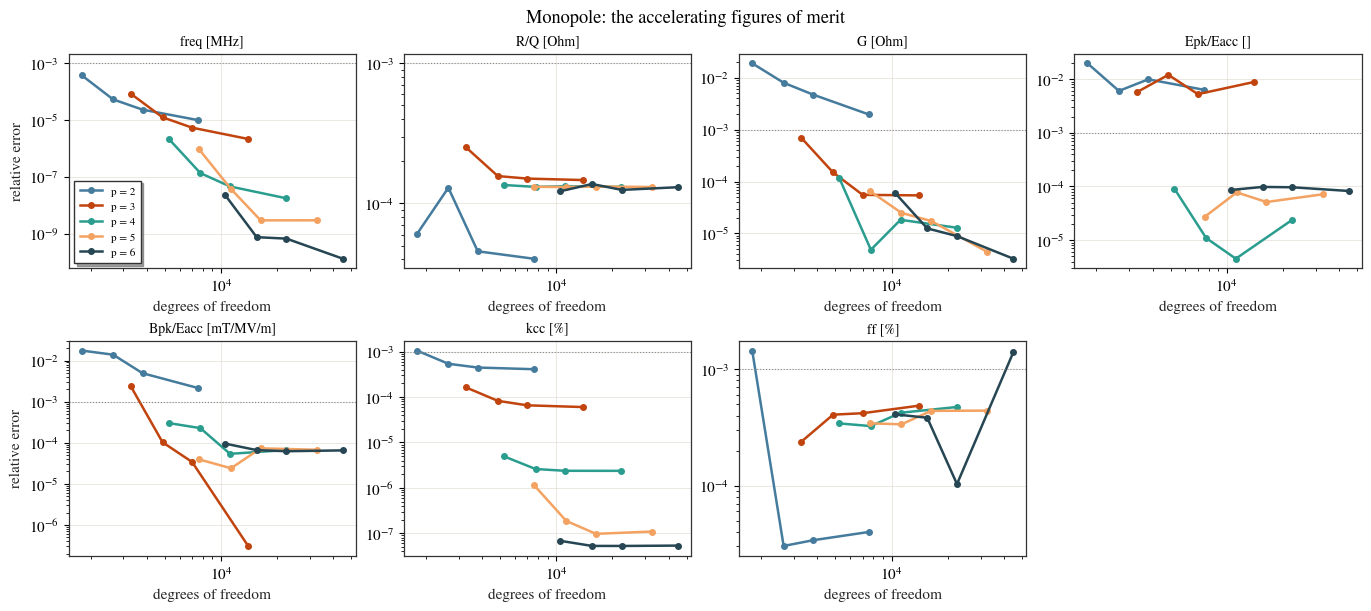

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='relative error'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='relative error'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='degrees of freedom'>,
        <Axes: >]], dtype=object)

In [5]:
def error_frame(df, ref_row, qois):
    '''Relative error of each QOI against the reference solve.'''
    out = df[['h', 'p', 'ndof']].copy()
    for q in qois:
        r = float(ref_row[q])
        out[q] = np.abs(df[q] - r) / (abs(r) if abs(r) > 1e-12 else 1.0)
    return out


def plot_convergence(err, qois, title, x='ndof', xlabel='degrees of freedom',
                     by='p', logx=True):
    ncols = 4
    nrows = int(np.ceil(len(qois) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.0 * nrows),
                             squeeze=False, layout='constrained')
    for ax, q in zip(axes.ravel(), qois):
        for i, (key, g) in enumerate(err.groupby(by)):
            g = g.sort_values(x)
            ax.plot(g[x], g[q].replace(0, np.nan), 'o-', ms=4,
                    color=WARM[i % len(WARM)], label=f'{by} = {key}')
        if logx:
            ax.set_xscale('log')
        ax.set_yscale('log')
        ax.axhline(1e-3, color='#888888', lw=0.8, ls=':')
        ax.set_title(q, fontsize=10)
        ax.set_xlabel(xlabel)
    for row in axes:
        row[0].set_ylabel('relative error')
    axes[0, 0].legend(fontsize=8)
    for ax in axes.ravel()[len(qois):]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()
    return axes


err_mono = error_frame(mono, ref['monopole'], LONGITUDINAL)
err_dip = error_frame(dip, ref['dipole'], TRANSVERSE)
plot_convergence(err_mono, LONGITUDINAL, 'Monopole: the accelerating figures of merit')

The two families separate immediately. `freq`, `R/Q` and `kcc` are already at or below
0.1 % on the very coarsest mesh in the grid — they converge so fast that this grid cannot
resolve their rate — and `G` joins them one order later. The peak-field ratios are still
around half a percent at `p = 2` on the *finest* mesh here, and only drop to the level of
the others once the order reaches 4.

`ff` is the odd one out and repays a careful look. Its error is small in absolute terms on
this cavity, but it does not shrink: it sits at a few parts in $10^4$ at every order and is
no better at `p = 6` than at `p = 3`. Field flatness is the ratio of the on-axis field
*maxima* cell to cell, so it inherits the convergence behaviour of a maximum rather than of
an integral, and a quantity that stops improving under refinement should never be quoted to
more precision than it has earned.

## 5. The transverse case

The same for the dipole, including the transverse `R/Q`. It is worth checking separately,
because the transverse voltage is not an on-axis integral: it is built from a line integral
at a radius $r_0$ inside the aperture plus the Panofsky-Wenzel relation, so it samples the
field where the mesh is coarser and could in principle converge differently from the
longitudinal one.

It does not — the transverse `R/Q` converges as cleanly as the longitudinal one, which is
the reassuring half of this section. The unreassuring half is the dipole's peak-field
ratios: they are the worst-behaved quantities anywhere in this notebook, still 2 % out at
`p = 3` and needing `p = 5` before they settle. A deflecting mode concentrates its surface
field into a smaller region than the accelerating mode does, and a maximum over a sharper
peak is harder to resolve.

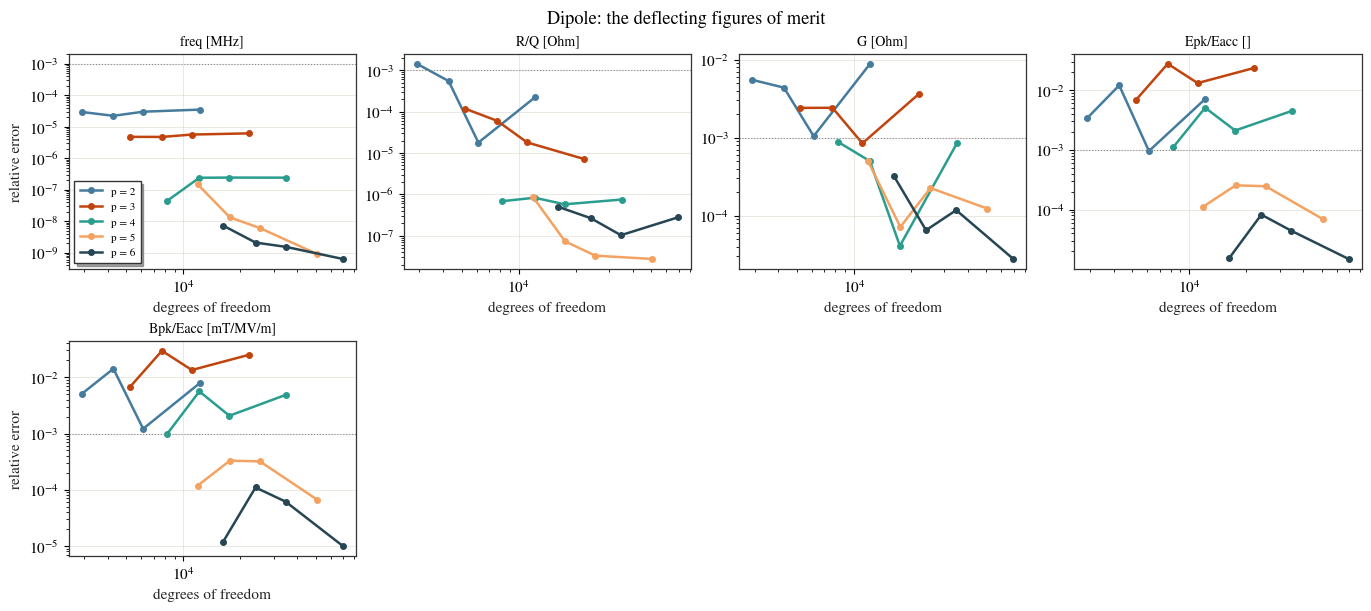

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='degrees of freedom', ylabel='relative error'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='degrees of freedom'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='degrees of freedom'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='degrees of freedom', ylabel='relative error'>,
        <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [6]:
plot_convergence(err_dip, TRANSVERSE, 'Dipole: the deflecting figures of merit')

## 6. Which knob actually moves them

Plot the same errors against the polynomial order at each element size, and then against
the element size at each order. The asymmetry is the practical lesson of this notebook:
the peak-field ratios fall by orders of magnitude with `p` and are essentially flat in `h`.

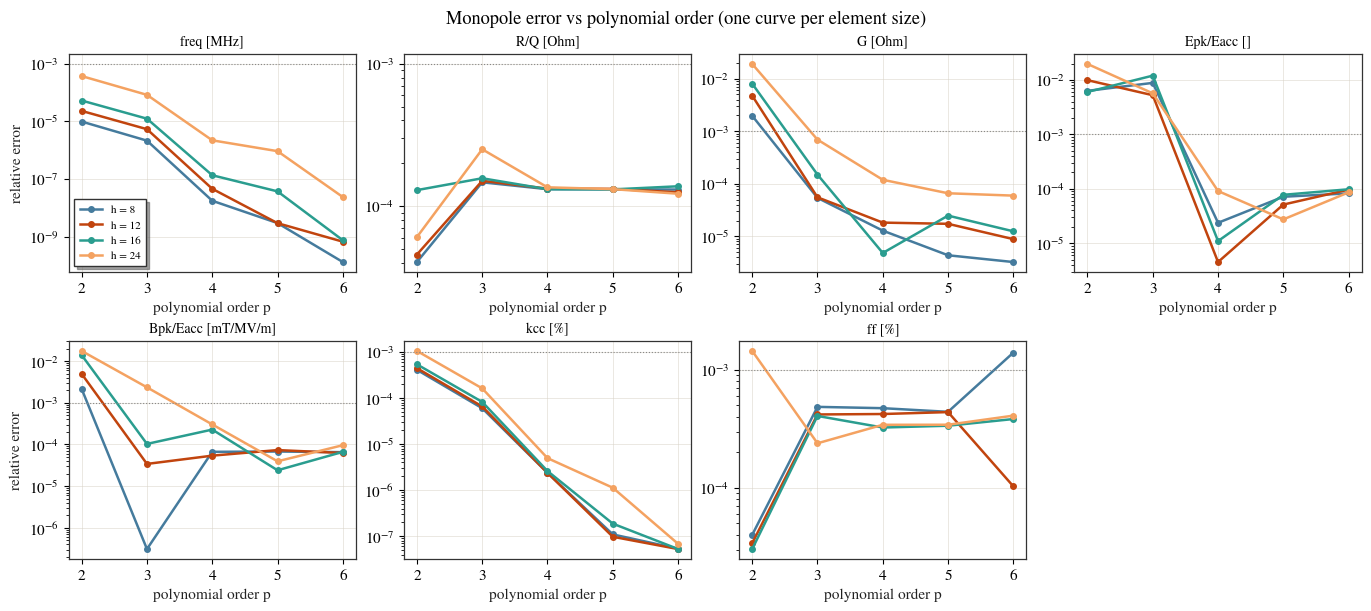

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='polynomial order p', ylabel='relative error'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='polynomial order p'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='polynomial order p'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='polynomial order p'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='polynomial order p', ylabel='relative error'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='polynomial order p'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='polynomial order p'>,
        <Axes: >]], dtype=object)

In [7]:
plot_convergence(err_mono, LONGITUDINAL,
                 'Monopole error vs polynomial order (one curve per element size)',
                 x='p', xlabel='polynomial order p', by='h', logx=False)

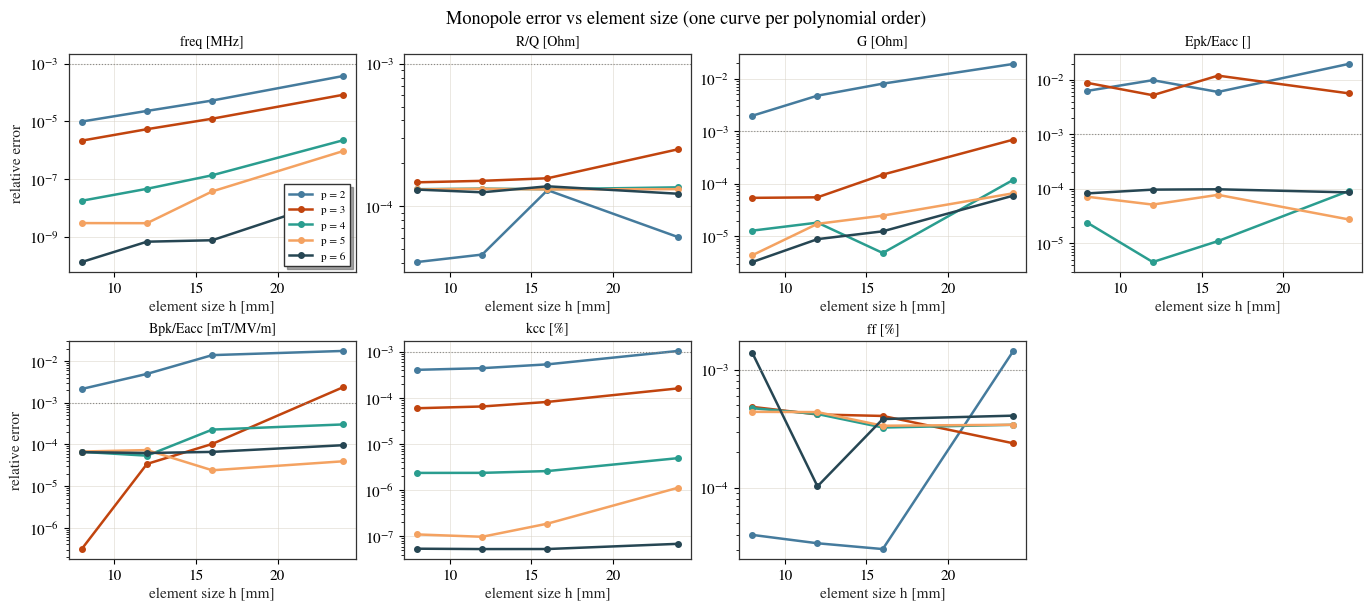

array([[<Axes: title={'center': 'freq [MHz]'}, xlabel='element size h [mm]', ylabel='relative error'>,
        <Axes: title={'center': 'R/Q [Ohm]'}, xlabel='element size h [mm]'>,
        <Axes: title={'center': 'G [Ohm]'}, xlabel='element size h [mm]'>,
        <Axes: title={'center': 'Epk/Eacc []'}, xlabel='element size h [mm]'>],
       [<Axes: title={'center': 'Bpk/Eacc [mT/MV/m]'}, xlabel='element size h [mm]', ylabel='relative error'>,
        <Axes: title={'center': 'kcc [%]'}, xlabel='element size h [mm]'>,
        <Axes: title={'center': 'ff [%]'}, xlabel='element size h [mm]'>,
        <Axes: >]], dtype=object)

In [8]:
plot_convergence(err_mono, LONGITUDINAL,
                 'Monopole error vs element size (one curve per polynomial order)',
                 x='h', xlabel='element size h [mm]', by='p', logx=False)

## 7. The trap, drawn directly

A relative error hides the sign of the mistake. Plot the two peak-field ratios themselves
against element size, one line per order, and the failure at low order is unmistakable: at
`p = 2` the value moves up and down as the mesh is refined, while the high orders settle
onto a flat line at the converged answer.

Non-monotonic wander is the signature to watch for. A quantity approaching its limit from
one side is converging, however slowly; a quantity that bounces is not converging at all,
and no amount of `h` refinement will make it.

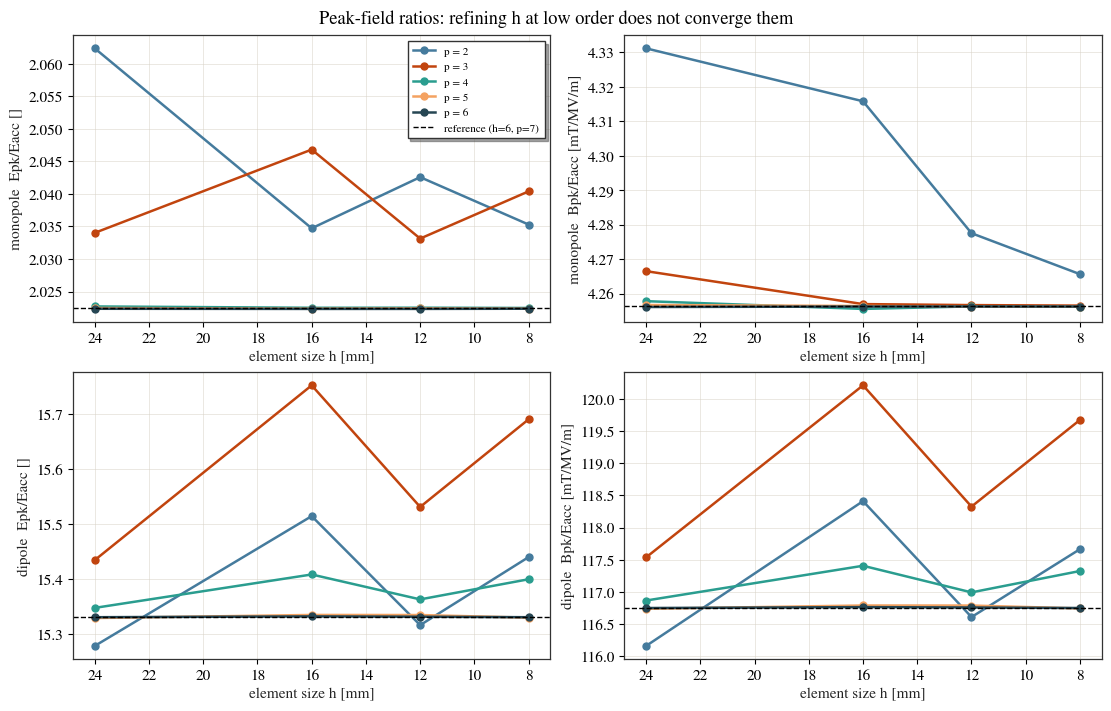

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout='constrained')
for row, (frame, kind) in enumerate(((mono, 'monopole'), (dip, 'dipole'))):
    for ax, q in zip(axes[row], ['Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]']):
        for i, (p, g) in enumerate(frame.groupby('p')):
            g = g.sort_values('h')
            ax.plot(g['h'], g[q], 'o-', ms=5, color=WARM[i % len(WARM)], label=f'p = {p}')
        ax.axhline(ref[kind][q], color='k', lw=1, ls='--',
                   label=f'reference (h={REF_H}, p={REF_P})')
        ax.set_xlabel('element size h [mm]')
        ax.set_ylabel(f'{kind}  {q}')
        ax.invert_xaxis()                      # finer meshes to the right
axes[0, 0].legend(fontsize=8)
fig.suptitle('Peak-field ratios: refining h at low order does not converge them')
plt.show()

## 8. The numbers

The relative error of every figure of merit at each polynomial order, on the finest
element size in the grid. This is the table to read before choosing a mesh for a study:
the row tells you what that order costs you on that quantity.

In [10]:
def error_by_order(err, qois, h):
    g = err[err['h'] == h].set_index('p')
    return g[qois].T


finest = min(GRID_H)
pd.concat({'monopole': error_by_order(err_mono, LONGITUDINAL, finest),
           'dipole': error_by_order(err_dip, TRANSVERSE, finest)}).map(
    lambda v: f'{v:.1e}')

p                                  2        3        4        5        6
monopole freq [MHz]          9.9e-06  2.2e-06  1.8e-08  2.9e-09  1.3e-10
         R/Q [Ohm]           4.0e-05  1.5e-04  1.3e-04  1.3e-04  1.3e-04
         G [Ohm]             2.0e-03  5.4e-05  1.3e-05  4.4e-06  3.2e-06
         Epk/Eacc []         6.3e-03  8.8e-03  2.4e-05  7.2e-05  8.3e-05
         Bpk/Eacc [mT/MV/m]  2.1e-03  3.1e-07  6.6e-05  6.8e-05  6.5e-05
         kcc [%]             4.1e-04  6.0e-05  2.4e-06  1.1e-07  5.4e-08
         ff [%]              4.0e-05  4.9e-04  4.7e-04  4.4e-04  1.4e-03
dipole   freq [MHz]          3.5e-05  6.2e-06  2.4e-07  9.1e-10  6.3e-10
         R/Q [Ohm]           2.2e-04  7.2e-06  7.5e-07  2.7e-08  2.8e-07
         G [Ohm]             8.8e-03  3.7e-03  8.4e-04  1.2e-04  2.8e-05
         Epk/Eacc []         7.1e-03  2.4e-02  4.5e-03  6.9e-05  1.5e-05
         Bpk/Eacc [mT/MV/m]  7.8e-03  2.5e-02  4.9e-03  6.7e-05  1.0e-05

## 9. What it costs to reach 0.1 %

For each figure of merit, the cheapest solve in the grid that reaches 0.1 % of the reference
*and stays there on every finer mesh at that order*. The second condition matters: a
quantity that wanders can cross the right answer on a coarse mesh and leave again, and a
table built on single crossings would recommend exactly the meshes this notebook warns
about. A blank row means nothing in the grid qualified.

In [11]:
def cheapest_within(err, qois, tol=1e-3):
    '''The cheapest solve within `tol` that STAYS within it on every finer mesh.

    A single point inside the tolerance proves nothing for a quantity that wanders:
    a coarse mesh can cross the right answer on its way past. Requiring every finer
    element size at that order to hold the tolerance too is what distinguishes
    convergence from a lucky crossing.
    '''
    rows = {}
    for q in qois:
        best = None
        for _, r in err.sort_values('ndof').iterrows():
            same_order = err[(err['p'] == r['p']) & (err['h'] <= r['h'])]
            if (same_order[q] <= tol).all():
                best = r
                break
        rows[q] = ({'h [mm]': int(best['h']), 'p': int(best['p']),
                    'DOFs': int(best['ndof'])}
                   if best is not None else
                   {'h [mm]': None, 'p': None, 'DOFs': None})
    return pd.DataFrame(rows).T


pd.concat({'monopole': cheapest_within(err_mono, LONGITUDINAL),
           'dipole': cheapest_within(err_dip, TRANSVERSE)})

h [mm]  p   DOFs
monopole freq [MHz]              24  2   1791
         R/Q [Ohm]               24  2   1791
         G [Ohm]                 24  3   3288
         Epk/Eacc []             24  4   5235
         Bpk/Eacc [mT/MV/m]      16  3   4860
         kcc [%]                 16  2   2640
         ff [%]                  16  2   2640
dipole   freq [MHz]              24  2   2908
         R/Q [Ohm]               16  2   4276
         G [Ohm]                 24  4   8221
         Epk/Eacc []             24  5  11890
         Bpk/Eacc [mT/MV/m]      24  5  11890

## Reading it

- Check convergence per figure of merit, never once for the whole solve. The quantity you
  are about to report may be the slowest in the set, and the frequency is no guide to it —
  here it is the best-behaved number by five orders of magnitude.
- Integral quantities — `R/Q` longitudinal and transverse, `G`, `kcc` and the frequency —
  converge quickly and arrive first, often before the coarsest mesh you would think of
  using.
- Quantities built from field *maxima* arrive last. Both peak-field ratios need `p = 4`
  (monopole) or `p = 5` (dipole) before they join the others; at `p = 2` they are around
  half a percent out on the finest mesh here, and the dipole's are 2 % out at `p = 3`.
- `ff` never converges on this grid at all. It is small, but it stops improving, so treat
  it as a quantity with a floor rather than one you can refine your way out of.
- Reach for `p` before `h` on those quantities. Two reasons: the order is what resolves the
  shape of the field inside an element, and on a curved geometry like this one the mesher's
  own curvature refinement already sets the element count, so `h` buys far less than its
  value suggests.
- Do not accept a single point inside your tolerance as evidence of convergence. A quantity
  that wanders will cross the right answer on the way past; require the tolerance to hold on
  every finer mesh, as section 9 does.
- Match modes across meshes by frequency, not by index, or a mode swap will read as a
  convergence failure.
- Before any tolerance, uncertainty or sensitivity study, confirm that the figures of merit
  it will report are converged on the mesh it will use. The perturbation those studies apply
  is small, and an unconverged quantity responds to the mesh more than to the geometry.

See also [Mesh convergence: how fine is fine enough?](mesh_convergence.ipynb), which checks
the fundamental frequency against a closed-form answer using adaptive refinement, and
[Multicell UQ and sensitivity analysis](multicell_uq_sa.ipynb), the study whose figures of
merit this one qualifies.